## import

In [18]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [20]:
# import yaml
import matplotlib.pyplot as plt
from auditoryforage.utils import plot_AF_episode
from ult import *
import multiprocessing
import seaborn as sns
from collections import defaultdict
import numpy as np

import multiprocessing as mp
from multiprocessing import Pool
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForaging as AF


## Analysis within trial

### Visualize episode

In [21]:
food_reward_list = np.linspace(10,2500,5)
env_param = [0, 1500, 0.087213, .25, -30, 0, 0]
task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

agent = PPO.load('ycstore/15thcheckpoint', env=taskbelief, device='cpu')

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [22]:
task.lick_cost, task.attention_cost_coeff, task.attention_cost_temp, task.penalty_cost, task.iti_cost,task.time_in_game_reward

(0, 0.087213, 0.25, -30, 0, 0)

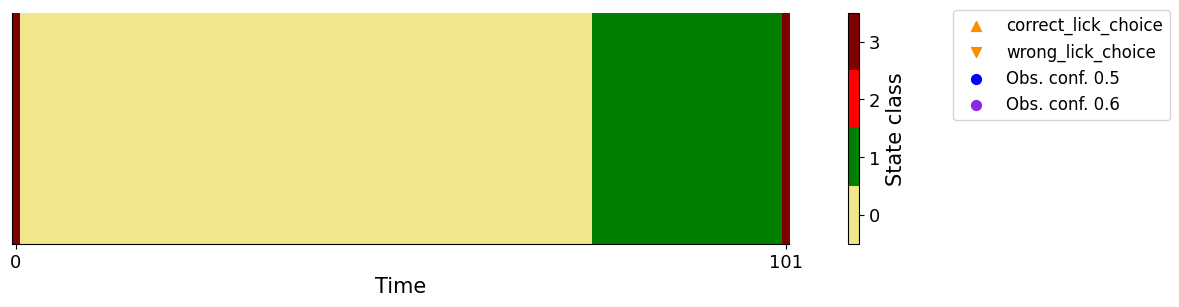

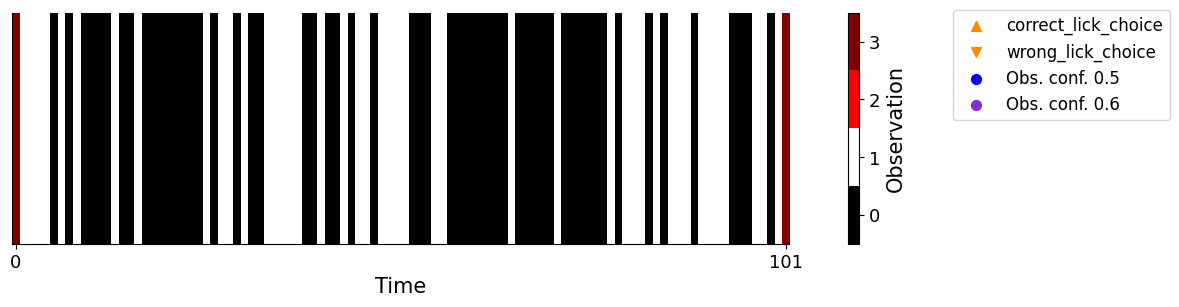

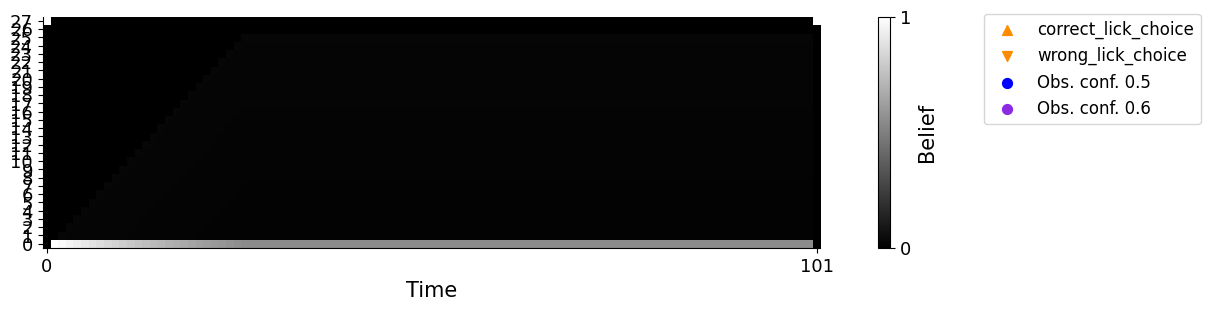

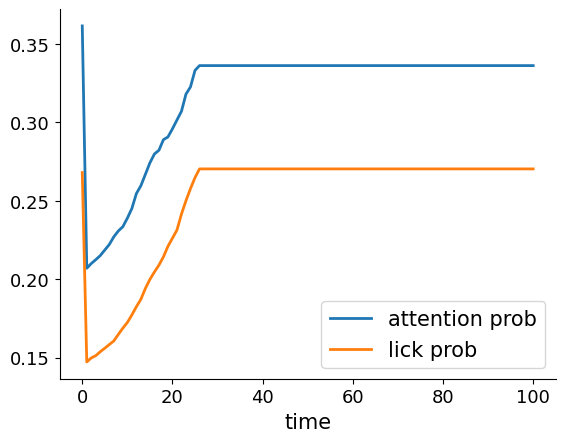

In [23]:
episode = run_one_episode(task, taskbelief, agent,
                          num_steps=1000)
fig = plot_AF_episode(episode, task, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())


lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.xlabel('time')
plt.legend()
plt.show()

## Analysis over trials

### Time analysis - plots

In [24]:
# run mp job
num_episodes = 1000

def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                              num_steps=100000)
    return episode

with multiprocessing.Pool(processes=13) as pool:
    all_episode_data = pool.map(eval_wrapper, range(num_episodes))

all_reward_res={} # k: v = foodreward: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list=[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,lick_time_list,att_time_list

for episode in all_episode_data:
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))

food reward idx: 0


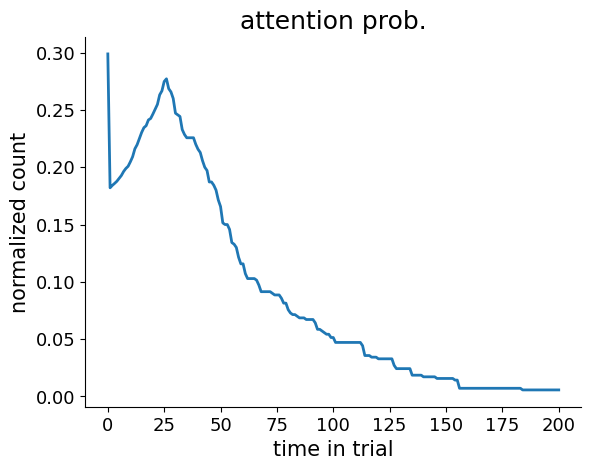

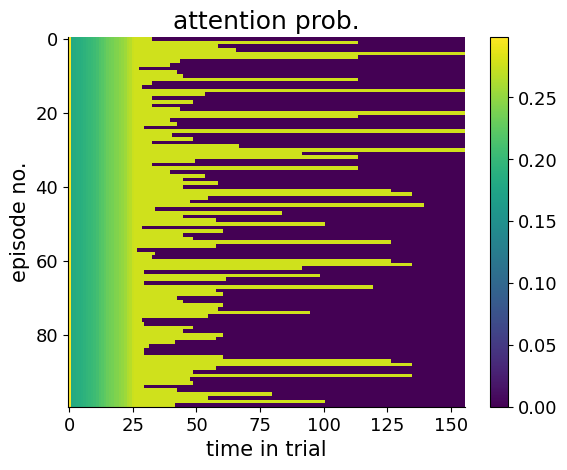

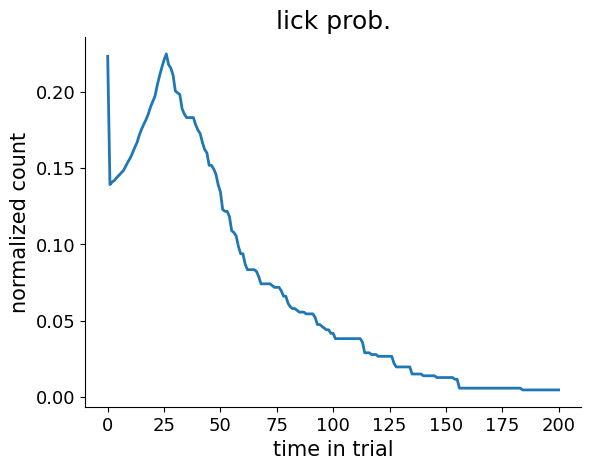

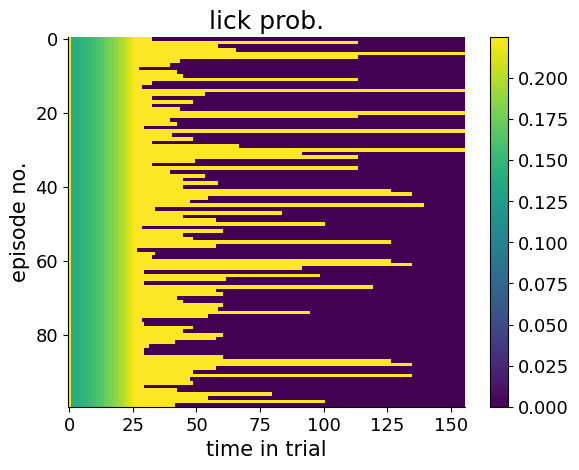

bad food reward idx: 0
food reward idx: 1


<Figure size 640x480 with 0 Axes>

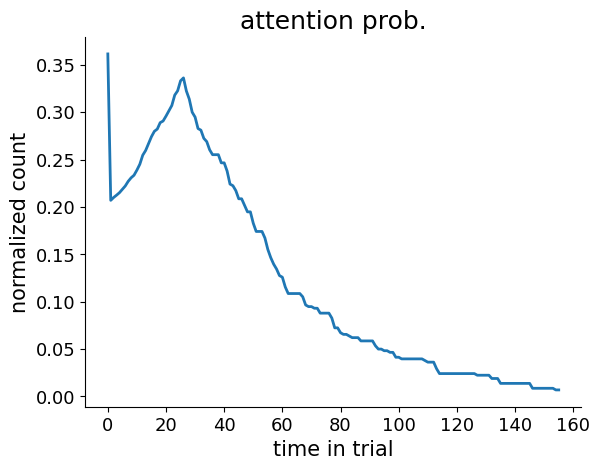

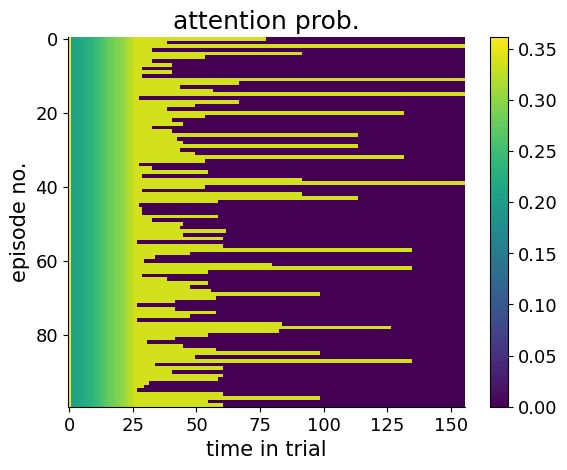

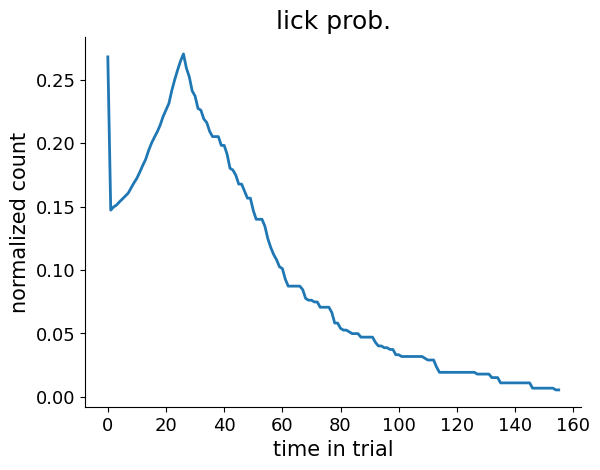

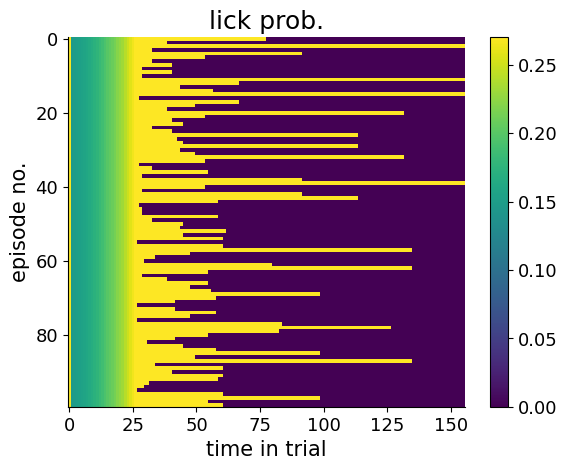

bad food reward idx: 1
food reward idx: 2


<Figure size 640x480 with 0 Axes>

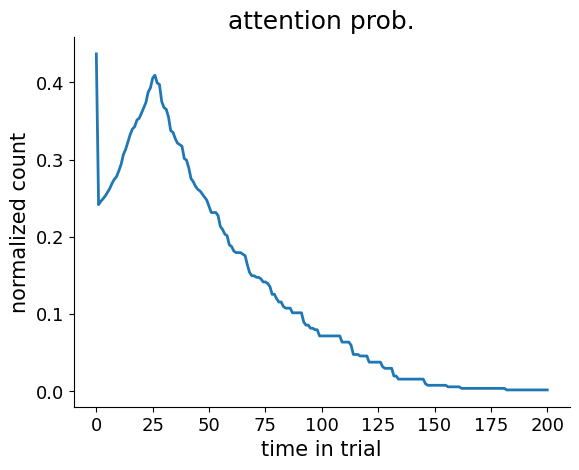

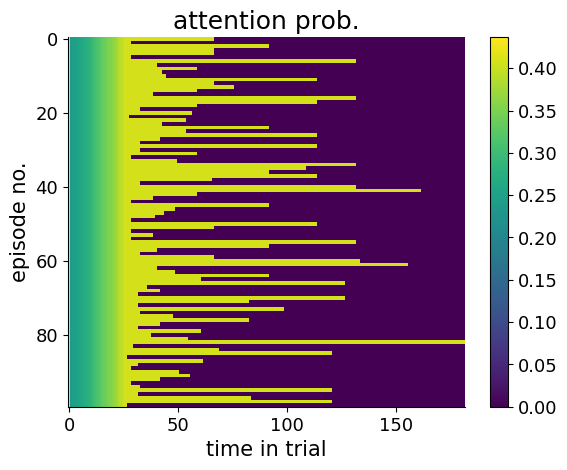

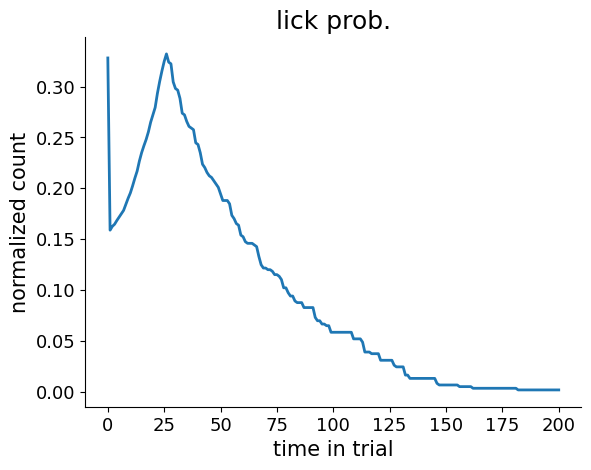

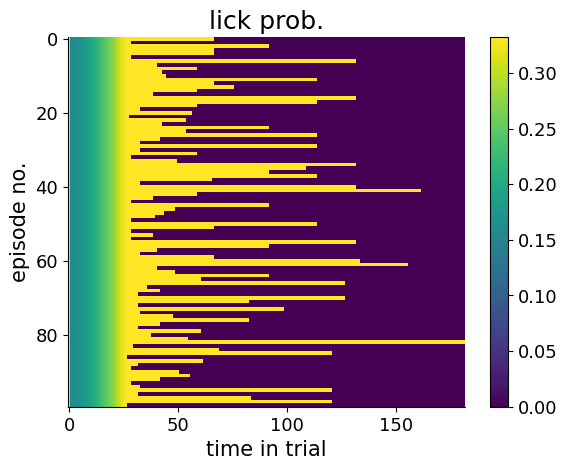

bad food reward idx: 2
food reward idx: 3


<Figure size 640x480 with 0 Axes>

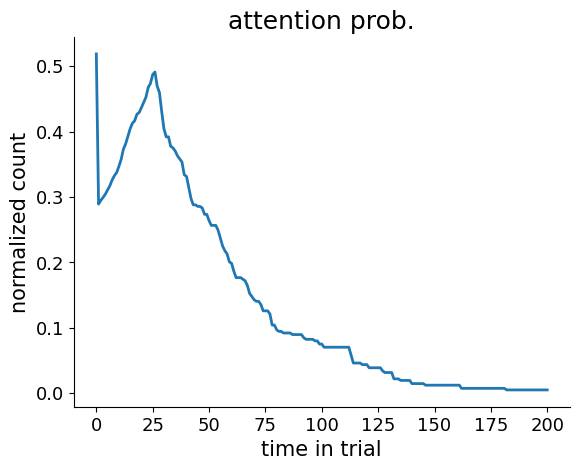

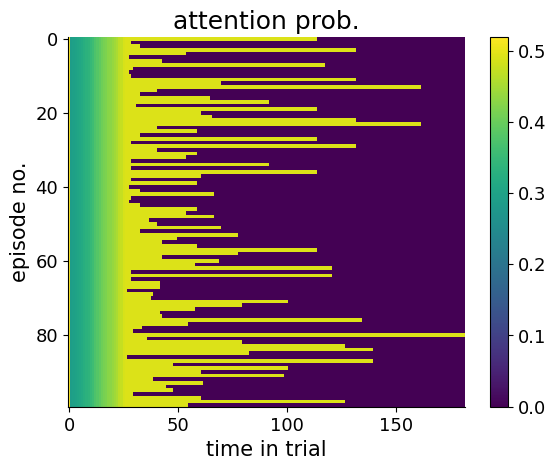

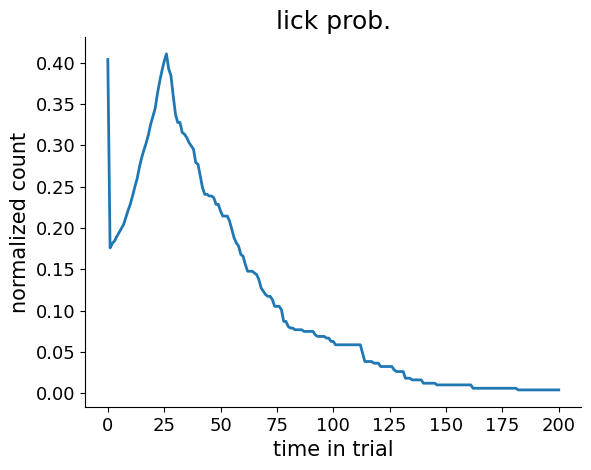

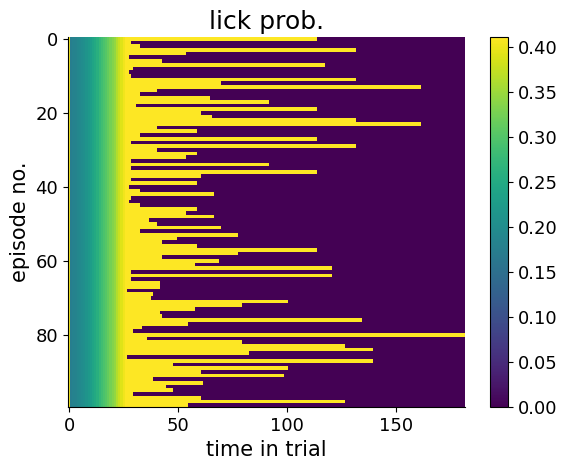

bad food reward idx: 3
food reward idx: 4


<Figure size 640x480 with 0 Axes>

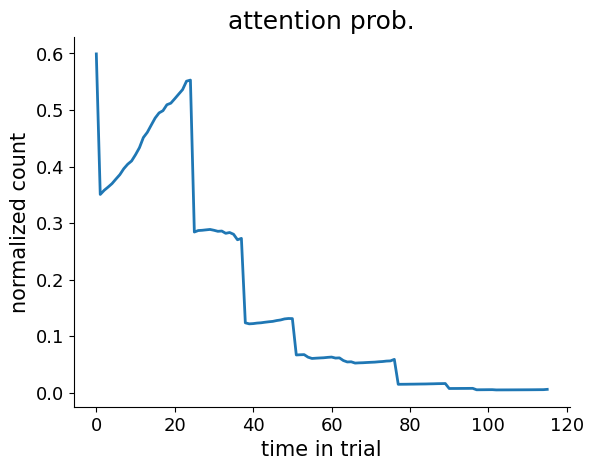

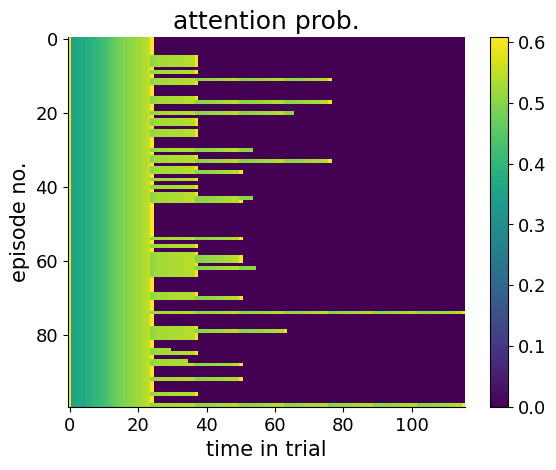

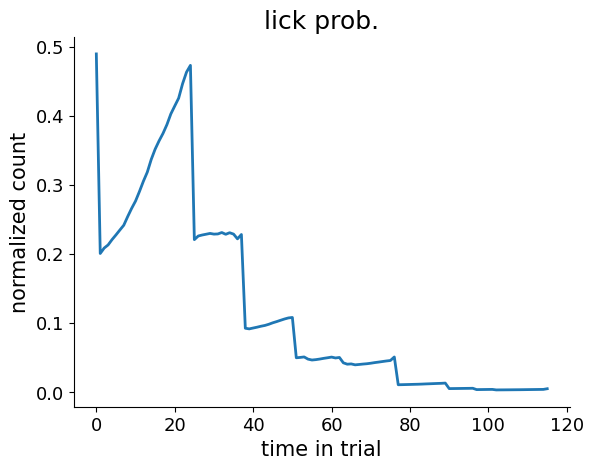

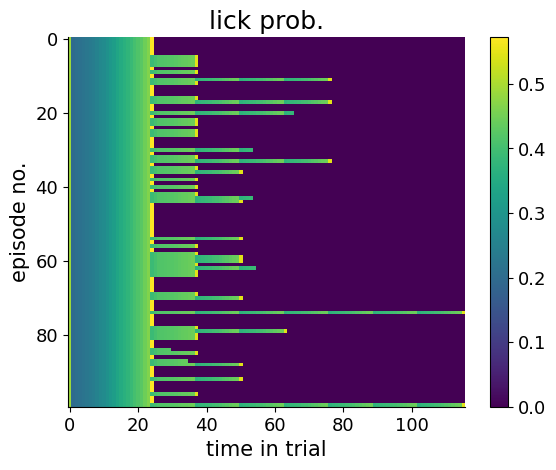

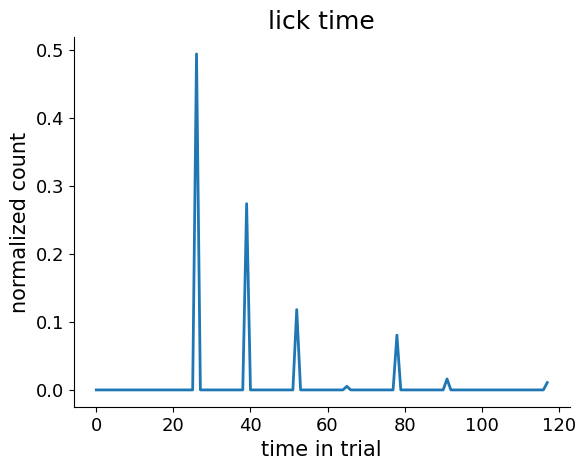

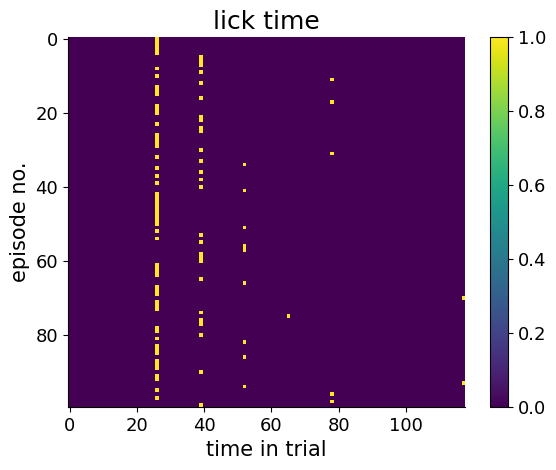

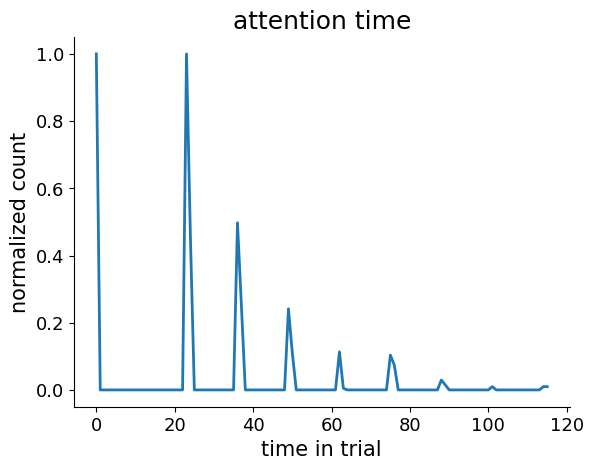

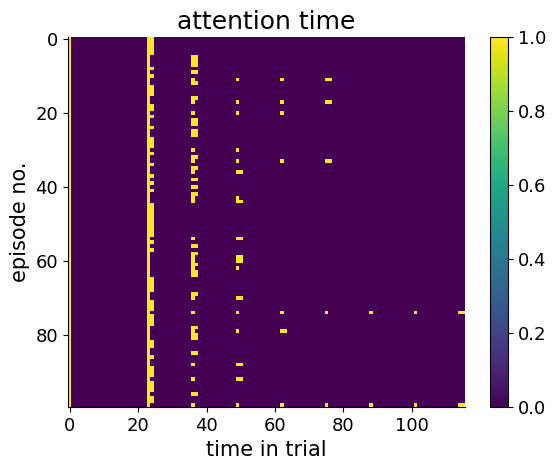

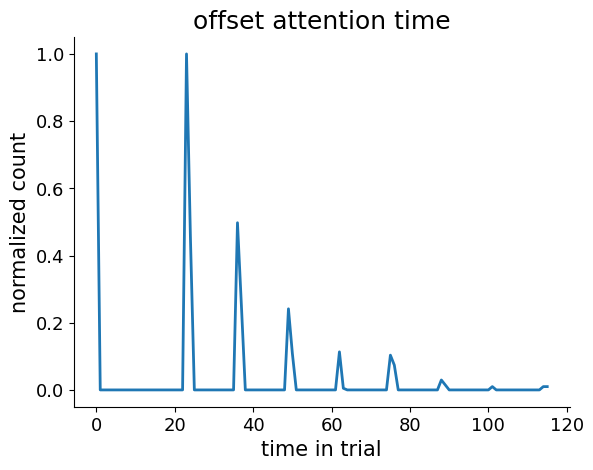

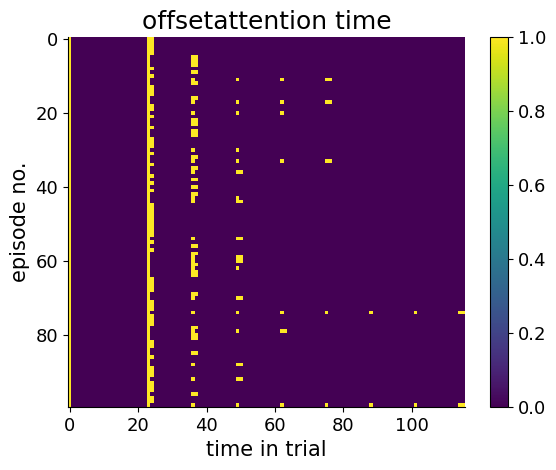

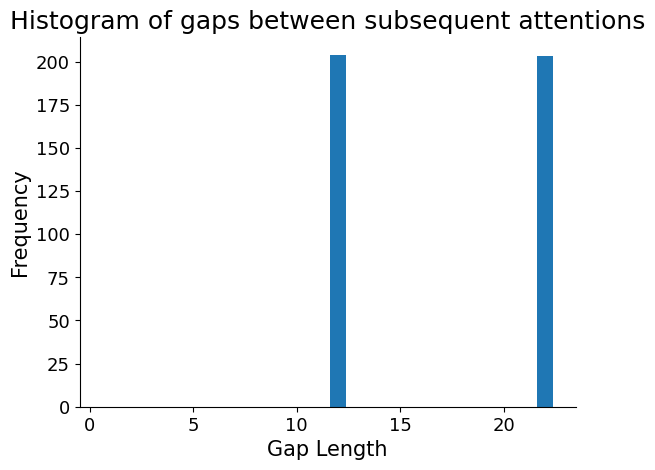

In [25]:
for food_reward_idx in all_reward_res.keys():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list=all_reward_res[food_reward_idx]
    print(f'food reward idx: {food_reward_idx}')
    try:
        plot_over_episodes(attention_prob_list, title = 'attention prob.', plot_no_episodes = 100)
        plot_over_episodes(lick_prob_list, title = 'lick prob.', plot_no_episodes = 100)
        plot_over_episodes(lick_time_list, title = 'lick time', plot_no_episodes = 100)
        plot_over_episodes(att_time_list, title = 'attention time', plot_no_episodes = 100)
    except:
        print(f'bad food reward idx: {food_reward_idx}')
        continue